In [1]:
# Global switch for expensive test-set inference in legacy cells.
# The matched-count Experiment 2 section below also defines RUN_TEST_INFERENCE = False
# and links test predictions by exact selected checkpoint filename.
RUN_TEST_INFERENCE = False


# experiment 1


Selected runs:
auprc     auroc  epoch  seed  timestep
0.373447  0.770488     94     0         1
0.363009  0.753016     35     1         1
0.377469  0.764679     59     2         1
0.382345  0.775329     89     3         1
0.355122  0.752636     62     4         1
0.388768  0.772463     58     0         2
0.385208  0.766522     60     1         2
0.378108  0.763186     87     2         2
0.390922  0.766076     91     3         2
0.378478  0.769356     79     4         2
0.370163  0.768867     55     0         4
0.376685  0.764763     56     1         4
0.372705  0.766493     48     2         4
0.375986  0.765392     86     3         4
0.374956  0.763407     90     4         4
0.363877  0.762593     98     0         8
0.382160  0.766517     57     1         8
0.374329  0.762674     72     2         8
0.368798  0.758103     45     3         8
0.362096  0.756643     51     4         8
0.354942  0.744280     39     0        12
0.378930  0.758148     46     1        12
0.357096  0.759668   

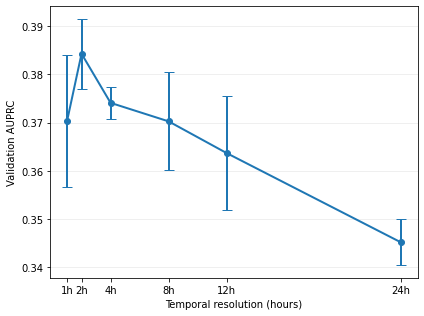

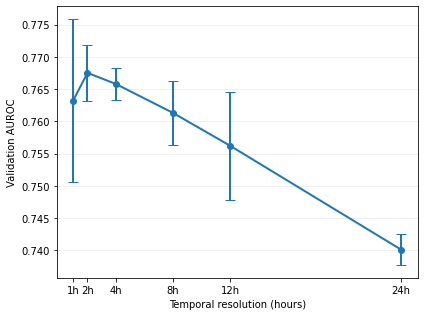

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


RESULTS_DIR = Path("/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality")
TIMESTEPS = [1, 2, 4, 8, 12, 24]


def load_results():
    rows = []

    for timestep in TIMESTEPS:
        log_dir = RESULTS_DIR / f"{timestep}h" / "keras_logs"

        # Only use seeded runs; ignore the older unseeded CSVs.
        files = sorted(log_dir.glob("*.seed*.csv"))

        for path in files:
            match = re.search(r"seed(\d+)", path.name)
            if match is None:
                continue

            seed = int(match.group(1))

            # Logs are semicolon-separated.
            df = pd.read_csv(path, sep=";")

            # Select checkpoint/epoch by validation AUPRC.
            best_idx = df["val_auprc"].idxmax()
            best = df.loc[best_idx]

            rows.append(
                {
                    "timestep": timestep,
                    "seed": seed,
                    "epoch": int(best["epoch"]),
                    "auprc": best["val_auprc"],
                    # AUROC from the SAME selected epoch.
                    "auroc": best["val_auroc"],
                }
            )

    return pd.DataFrame(rows)


def summarize(df, metric):
    rows = []

    for timestep, group in df.groupby("timestep"):
        values = np.asarray(group[metric].values)
        n = len(values)

        mean = values.mean()
        sd = values.std(ddof=1)
        sem = sd / np.sqrt(n)

        # Two-sided 95% Student-t confidence interval.
        critical = t.ppf(0.975, df=n - 1)
        ci = critical * sem

        rows.append(
            {
                "timestep": timestep,
                "mean": mean,
                "sd": sd,
                "ci95": ci,
                "n": n,
            }
        )

    return pd.DataFrame(rows).sort_values("timestep")


def plot_metric(summary, metric_name, output_file):
    x = np.asarray(summary["timestep"].values)
    y = np.asarray(summary["mean"].values)
    ci = np.asarray(summary["ci95"].values)

    plt.figure(figsize=(6, 4.5))

    plt.errorbar(
        x,
        y,
        yerr=ci,
        marker="o",
        capsize=5,
        linewidth=2,
        markersize=6,
    )

    plt.xlabel("Temporal resolution (hours)")
    plt.ylabel(metric_name)
    plt.xticks(TIMESTEPS, [f"{x}h" for x in TIMESTEPS])

    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()


df = load_results()

print("\nSelected runs:")
print(df.to_string(index=False))

auprc_summary = summarize(df, "auprc")
auroc_summary = summarize(df, "auroc")

print("\nAUPRC:")
print(auprc_summary.to_string(index=False))

print("\nAUROC:")
print(auroc_summary.to_string(index=False))

plot_metric(
    auprc_summary,
    metric_name="Validation AUPRC",
    output_file="experiment1_auprc_ci.png",
)

plot_metric(
    auroc_summary,
    metric_name="Validation AUROC",
    output_file="experiment1_auroc_ci.png",
)

In [3]:
from pathlib import Path
import re
import subprocess
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc


# ---------------------------------------------------------------------
# Paths / experiment settings
# ---------------------------------------------------------------------

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/in-hospital-mortality"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality"
)

NETWORK = "mimic4models/keras_models/lstm.py"

TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]
SEEDS = [0, 1, 2, 3, 4]

ONLY_COMPLETE = False
EXPECTED_EPOCHS = 100


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def parse_run_from_filename(path):
    """Parse timestep and seed from a log/prediction filename."""
    m = re.search(
        r"\.ts(?P<timestep>[0-9.]+)"
        r".*\.seed(?P<seed>\d+)",
        path.name,
    )

    if m is None:
        return None

    return {
        "timestep": float(m.group("timestep")),
        "seed": int(m.group("seed")),
    }


def find_best_epoch(log_path):
    """Select checkpoint using highest validation AUPRC."""
    df = pd.read_csv(str(log_path), sep=";")

    if len(df) == 0:
        return None

    if ONLY_COMPLETE and len(df) < EXPECTED_EPOCHS:
        return None

    best_idx = df["val_auprc"].idxmax()
    row = df.loc[best_idx]

    return {
        "csv_epoch": int(row["epoch"]),
        "val_auprc": float(row["val_auprc"]),
        "val_auroc": float(row["val_auroc"]),
        "n_epochs": len(df),
    }


def find_checkpoint(log_path, csv_epoch):
    """Map zero-indexed CSV epoch to the corresponding one-indexed checkpoint."""
    state_dir = log_path.parent.parent / "keras_states"
    checkpoint_epoch = csv_epoch + 1
    base = log_path.stem

    candidates = list(
        state_dir.glob(
            "{}.epoch{}.test*.state".format(base, checkpoint_epoch)
        )
    )

    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) == 0:
        return None

    raise RuntimeError(
        "Multiple checkpoints found for {} epoch {}:\n{}".format(
            log_path.name, checkpoint_epoch, candidates
        )
    )


def find_normalizer(timestep):
    pattern = (
        "ihm_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        .format(timestep)
    )
    candidates = list(NORM.glob(pattern))

    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) == 0:
        raise RuntimeError(
            "No normalizer found for timestep {}h using:\n{}".format(
                timestep, NORM / pattern
            )
        )
    raise RuntimeError(
        "Multiple normalizers found for timestep {}h:\n{}".format(
            timestep, candidates
        )
    )


def parse_test_metrics(stdout):
    auroc = None
    auprc = None

    m = re.search(r"AUC of ROC = ([0-9.eE+-]+)", stdout)
    if m:
        auroc = float(m.group(1))

    m = re.search(r"AUC of PRC = ([0-9.eE+-]+)", stdout)
    if m:
        auprc = float(m.group(1))

    return auroc, auprc


def compute_test_metrics_from_prediction(path):
    """Compute the same AUROC/AUPRC summary from an existing prediction CSV."""
    df = pd.read_csv(str(path))
    required = {"prediction", "y_true"}
    if not required.issubset(df.columns):
        raise ValueError(
            "Prediction file missing required columns {}: {}".format(
                required, path
            )
        )

    y = df["y_true"].values
    pred = df["prediction"].values
    auroc = roc_auc_score(y, pred)
    precision, recall, _ = precision_recall_curve(y, pred)
    auprc = auc(recall, precision)
    return auroc, auprc


def find_existing_prediction(timestep, seed):
    """
    Find an existing prediction file for this run.

    We intentionally do NOT compare timestamps/configs against training logs.
    When multiple matching files exist, use the most recently modified one.
    Set RUN_TEST_INFERENCE=True whenever predictions should be regenerated.
    """
    pred_dir = OUT / "{}h".format(int(timestep) if float(timestep).is_integer() else timestep) / "test_predictions"
    if not pred_dir.exists():
        return None

    candidates = []
    for path in pred_dir.glob("*.csv"):
        run = parse_run_from_filename(path)
        if run is None:
            continue
        if abs(run["timestep"] - float(timestep)) < 1e-6 and run["seed"] == int(seed):
            candidates.append(path)

    if not candidates:
        return None

    return max(candidates, key=lambda p: p.stat().st_mtime)


# ---------------------------------------------------------------------
# Evaluate all available Experiment 1 runs
# ---------------------------------------------------------------------

if RUN_TEST_INFERENCE:
    print("RUN_TEST_INFERENCE=True: rerunning test inference.")
else:
    print("RUN_TEST_INFERENCE=False: reusing existing test prediction CSVs.")

rows = []

for timestep in TIMESTEPS:
    log_dir = OUT / "{}h".format(timestep) / "keras_logs"

    if not log_dir.exists():
        print("Missing log directory: {}".format(log_dir))
        continue

    # Normalizer/checkpoint filesystem lookup is only needed when rerunning inference.
    normalizer = find_normalizer(float(timestep)) if RUN_TEST_INFERENCE else None

    for log_path in sorted(log_dir.glob("*.csv")):
        run = parse_run_from_filename(log_path)
        if run is None:
            continue
        if abs(run["timestep"] - timestep) > 1e-6:
            continue
        if run["seed"] not in SEEDS:
            continue

        best = find_best_epoch(log_path)
        if best is None:
            print("Skipping incomplete/empty run: {}".format(log_path.name))
            continue

        checkpoint = None
        if RUN_TEST_INFERENCE:
            checkpoint = find_checkpoint(log_path, best["csv_epoch"])
            if checkpoint is None:
                print(
                    "Checkpoint missing: ts={} seed={} best_csv_epoch={}".format(
                        run["timestep"], run["seed"], best["csv_epoch"]
                    )
                )
                continue

            cmd = [
                "python", "-u", "-m", "mimic4models.in_hospital_mortality.main",
                "--network", NETWORK,
                "--dim", "16",
                "--depth", "2",
                "--dropout", "0.3",
                "--mode", "test",
                "--batch_size", "8",
                "--timestep", str(run["timestep"]),
                "--seed", str(run["seed"]),
                "--data", str(DATA),
                "--normalizer_state", str(normalizer),
                "--output_dir", str(OUT / "{}h".format(timestep)),
                "--load_state", str(checkpoint),
            ]

            result = subprocess.run(
                cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                universal_newlines=True,
            )

            if result.returncode != 0:
                print("TEST FAILED: {}".format(checkpoint.name))
                print(result.stderr)
                continue

            test_auroc, test_auprc = parse_test_metrics(result.stdout)
            prediction_path = None
        else:
            prediction_path = find_existing_prediction(
                run["timestep"], run["seed"]
            )
            if prediction_path is None:
                print(
                    "Missing existing prediction: ts={} seed={}. "
                    "Set RUN_TEST_INFERENCE=True to generate it.".format(
                        run["timestep"], run["seed"]
                    )
                )
                continue

            test_auroc, test_auprc = compute_test_metrics_from_prediction(
                prediction_path
            )

        rows.append(
            {
                "timestep": run["timestep"],
                "seed": run["seed"],
                "n_epochs": best["n_epochs"],
                "best_csv_epoch": best["csv_epoch"],
                "checkpoint_epoch": best["csv_epoch"] + 1,
                "val_auprc": best["val_auprc"],
                "val_auroc": best["val_auroc"],
                "test_auprc": test_auprc,
                "test_auroc": test_auroc,
                "prediction_path": None if prediction_path is None else str(prediction_path),
            }
        )

results_exp1 = pd.DataFrame(rows)

if len(results_exp1) == 0:
    print("\nNo test results available.")
else:
    results_exp1 = (
        results_exp1
        .sort_values(["timestep", "seed"])
        .reset_index(drop=True)
    )

    print("\n\nEXPERIMENT 1 TEST RESULTS")
    print("=" * 100)
    print(
        results_exp1.to_string(
            index=False,
            float_format=lambda x: "{:.6f}".format(x),
        )
    )


RUN_TEST_INFERENCE=False: reusing existing test prediction CSVs.


EXPERIMENT 1 TEST RESULTS
best_csv_epoch  checkpoint_epoch  n_epochs                                    prediction_path  seed  test_auprc  test_auroc  timestep  val_auprc  val_auroc
            94                95       100  /heinz-georgenas/users/mingzhul/Simultaneous-E...     0    0.301848    0.736431  1.000000   0.373447   0.770488
            35                36       100  /heinz-georgenas/users/mingzhul/Simultaneous-E...     1    0.283528    0.713501  1.000000   0.363009   0.753016
            59                60       100  /heinz-georgenas/users/mingzhul/Simultaneous-E...     2    0.292707    0.732991  1.000000   0.377469   0.764679
            89                90       100  /heinz-georgenas/users/mingzhul/Simultaneous-E...     3    0.292709    0.733889  1.000000   0.382345   0.775329
            62                63       100  /heinz-georgenas/users/mingzhul/Simultaneous-E...     4    0.285016    0.706086  1.

In [4]:
summary_exp1 = (
    results_exp1
    .groupby("timestep")
    .agg({
        "seed": "count",
        "test_auprc": ["mean", "std"],
        "test_auroc": ["mean", "std"],
    })
    .reset_index()
)

# Flatten the multi-level column names
summary_exp1.columns = [
    "timestep",
    "n",
    "auprc_mean",
    "auprc_sd",
    "auroc_mean",
    "auroc_sd",
]

print(
    summary_exp1.to_string(
        index=False,
        float_format=lambda x: "{:.4f}".format(x),
    )
)

timestep  n  auprc_mean  auprc_sd  auroc_mean  auroc_sd
  1.0000  5      0.2912    0.0073      0.7246    0.0138
  2.0000  5      0.3026    0.0030      0.7369    0.0053
  4.0000  5      0.2923    0.0120      0.7236    0.0055
  8.0000  5      0.2887    0.0057      0.7132    0.0027
 12.0000  5      0.2805    0.0057      0.7096    0.0040
 16.0000  5      0.2824    0.0072      0.7040    0.0029
 24.0000  5      0.2756    0.0030      0.6994    0.0054


In [5]:
reference = (
    results_exp1[results_exp1["timestep"] == 1]
    [["seed", "test_auprc", "test_auroc"]]
    .rename(
        columns={
            "test_auprc": "auprc_1h",
            "test_auroc": "auroc_1h",
        }
    )
)

drops_exp1 = results_exp1.merge(
    reference,
    on="seed",
    how="inner",
)

drops_exp1["auprc_drop"] = (
    drops_exp1["auprc_1h"]
    - drops_exp1["test_auprc"]
)

drops_exp1["auroc_drop"] = (
    drops_exp1["auroc_1h"]
    - drops_exp1["test_auroc"]
)

drop_summary_exp1 = (
    drops_exp1
    .groupby("timestep")
    .agg({
        "seed": "count",
        "auprc_drop": ["mean", "std"],
        "auroc_drop": ["mean", "std"],
    })
    .reset_index()
)

drop_summary_exp1.columns = [
    "timestep",
    "n",
    "auprc_drop_mean",
    "auprc_drop_sd",
    "auroc_drop_mean",
    "auroc_drop_sd",
]

print(
    drop_summary_exp1.to_string(
        index=False,
        float_format=lambda x: "{:.4f}".format(x),
    )
)

timestep  n  auprc_drop_mean  auprc_drop_sd  auroc_drop_mean  auroc_drop_sd
  1.0000  5           0.0000         0.0000           0.0000         0.0000
  2.0000  5          -0.0115         0.0086          -0.0123         0.0178
  4.0000  5          -0.0012         0.0153           0.0010         0.0177
  8.0000  5           0.0024         0.0117           0.0113         0.0127
 12.0000  5           0.0106         0.0123           0.0150         0.0158
 16.0000  5           0.0087         0.0104           0.0206         0.0164
 24.0000  5           0.0156         0.0090           0.0251         0.0178


# Experiment 2: matched-count A/B/C/D analysis

This section is the safe matched-count analysis for fixed-horizon ICU-exit. It supersedes the older Experiment 2 cells that matched test predictions by `(horizon, timestep, seed)` or file modification time. The analysis below:

- parses A/B/C/D conditions from validation log/checkpoint names,
- excludes partial runs and hyperparameter mismatches from final comparisons by default,
- links validation logs to the exact selected checkpoint and then to `selected_checkpoint.name + ".csv"`,
- keeps optional test inference disabled unless `RUN_TEST_INFERENCE = True`, and
- computes A-vs-B, B-vs-C, and B-vs-D paired patient-level bootstrap contrasts without ensembling model seeds.


In [ ]:
from __future__ import print_function

from pathlib import Path
import re
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    brier_score_loss,
)

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# Configuration
# ============================================================

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/length-of-stay"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit"
)

NETWORK = "mimic4models/keras_models/lstm.py"

# Primary matched-count configuration.
TARGET_RS = [4]
HORIZONS = [12, 24, 48, 96, 168]
EXPECTED_MODEL_SEEDS = [0, 1, 2, 3, 4]
EXPECTED_EPOCHS = 100
REQUIRE_COMPLETE_FOR_FINAL = True

# Never launch test inference unless this is explicitly changed by the user.
RUN_TEST_INFERENCE = False

N_BOOT = 2000
BOOTSTRAP_SEED = 12345

EXPECTED_CONFIG = {
    "network": NETWORK,
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_size": 8,
    "epochs": 100,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "sampling_seed": 100,
}

CONDITION_ORDER = ["A", "B", "C", "D"]
PRIMARY_CONTRASTS = [("A", "B"), ("B", "C"), ("B", "D")]
OPTIONAL_CONTRASTS = [("A", "D")]
METRICS = ["auroc", "auprc", "brier"]


def show_table(title, df, max_rows=50):
    print("\n" + title)
    print("=" * len(title))
    if df is None or len(df) == 0:
        print("<none>")
        return
    view = df.head(max_rows)
    if display is not None:
        display(view)
        if len(df) > max_rows:
            print("... {} more rows".format(len(df) - max_rows))
    else:
        print(view.to_string(index=False))


def compute_auprc(y, pred):
    precision, recall, _ = precision_recall_curve(y, pred)
    return auc(recall, precision)


def compute_metric(y, pred, metric):
    y = np.asarray(y)
    pred = np.asarray(pred)
    if metric == "auroc":
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, pred)
    if metric == "auprc":
        return compute_auprc(y, pred)
    if metric == "brier":
        return brier_score_loss(y, pred)
    raise ValueError("Unknown metric: {}".format(metric))


def metric_difference(left_value, right_value, metric):
    # Positive always means the left condition performs better.
    if metric == "brier":
        return right_value - left_value
    return left_value - right_value


def extract_patient_id(stay):
    stay = str(stay)
    m = re.match(r"^(\d+)_episode", stay)
    if m:
        return m.group(1)
    return stay.split("_")[0]


In [ ]:

# ============================================================
# Robust run parsing and exact checkpoint/prediction matching
# ============================================================

def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    if cast is not None:
        return cast(value)
    return value


def parse_run_from_filename(path, target_r):
    """Parse validation log/checkpoint/prediction identity from a filename."""
    name = path.name
    horizon = _search(r"\.h(\d+)", name, int)
    timestep = _search(r"\.ts([0-9.]+)", name, float)
    model_seed = _search(r"\.seed(\d+)(?:\.|$)", name, int)

    dim = _search(r"\.n(\d+)", name, int)
    dropout = _search(r"\.d([0-9.]+)\.dep", name, float)
    depth = _search(r"\.dep(\d+)", name, int)
    batch_size = _search(r"\.bs(\d+)", name, int)
    target_repl_coef = _search(r"\.trc([0-9.]+)", name, float, 0.0)
    has_l1 = re.search(r"\.L1[0-9.eE+-]+", name) is not None
    has_l2 = re.search(r"\.L2[0-9.eE+-]+", name) is not None

    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        sampling_strategy = "none"
        sampling_interval = None
        sampling_seed = None
    else:
        sampling_strategy = sample.group("strategy")
        sampling_interval = int(sample.group("interval"))
        sampling_seed = sample.group("sseed")
        sampling_seed = int(sampling_seed) if sampling_seed is not None else None

    condition = None
    r = target_r
    if sampling_strategy == "none" and timestep is not None and abs(timestep - 1.0) < 1e-6:
        condition = "A"
        r = target_r
    elif (sampling_strategy == "structured" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "B"
        r = sampling_interval
    elif (sampling_strategy == "random_matched" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "C"
        r = sampling_interval
    elif (sampling_strategy == "none" and timestep is not None
          and abs(timestep - float(target_r)) < 1e-6):
        condition = "D"
        r = target_r

    return {
        "filename": name,
        "horizon": horizon,
        "r": r,
        "condition": condition,
        "timestep": timestep,
        "model_seed": model_seed,
        "dim": dim,
        "depth": depth,
        "dropout": dropout,
        "batch_size": batch_size,
        "sampling_strategy": sampling_strategy,
        "sampling_interval": sampling_interval,
        "sampling_seed": sampling_seed,
        "target_repl_coef": target_repl_coef,
        "has_l1": has_l1,
        "has_l2": has_l2,
    }


def hyperparameter_mismatch_reason(run):
    reasons = []
    checks = [
        ("dim", EXPECTED_CONFIG["dim"]),
        ("depth", EXPECTED_CONFIG["depth"]),
        ("batch_size", EXPECTED_CONFIG["batch_size"]),
    ]
    for key, expected in checks:
        if run.get(key) != expected:
            reasons.append("{}={} expected {}".format(key, run.get(key), expected))
    if run.get("dropout") is None or abs(run.get("dropout") - EXPECTED_CONFIG["dropout"]) > 1e-9:
        reasons.append("dropout={} expected {}".format(run.get("dropout"), EXPECTED_CONFIG["dropout"]))
    if run.get("target_repl_coef") != EXPECTED_CONFIG["target_repl_coef"]:
        reasons.append("target_repl_coef={} expected {}".format(
            run.get("target_repl_coef"), EXPECTED_CONFIG["target_repl_coef"]))
    if run.get("has_l1"):
        reasons.append("L1 suffix present; expected l1=0")
    if run.get("has_l2"):
        reasons.append("L2 suffix present; expected l2=0")
    if run.get("condition") == "C" and run.get("sampling_seed") != EXPECTED_CONFIG["sampling_seed"]:
        reasons.append("sampling_seed={} expected {}".format(
            run.get("sampling_seed"), EXPECTED_CONFIG["sampling_seed"]))
    if run.get("model_seed") not in EXPECTED_MODEL_SEEDS:
        reasons.append(
            "model_seed={} not in expected {}".format(
                run.get("model_seed"),
                EXPECTED_MODEL_SEEDS,
            )
        )        
    return "; ".join(reasons)


def condition_description(condition):
    if condition == "A":
        return "standard 1h"
    if condition == "B":
        return "structured-r + 1h"
    if condition == "C":
        return "random matched-count-r + 1h"
    if condition == "D":
        return "existing r-hour representation"
    return "outside A/B/C/D"


def read_validation_log(log_path):
    df = pd.read_csv(str(log_path), sep=";")
    if len(df) == 0:
        return None
    best_idx = df["val_auprc"].idxmax()
    best = df.loc[best_idx]
    n_epochs = len(df)
    return {
        "n_epochs": n_epochs,
        "complete": n_epochs >= EXPECTED_EPOCHS,
        "best_val_epoch": int(best["epoch"]),
        "best_val_auprc": float(best["val_auprc"]),
        "val_auroc_at_best_auprc": float(best["val_auroc"]),
    }


def find_selected_checkpoint(log_path, best_val_epoch):
    # CSVLogger epoch is zero-indexed in this benchmark; checkpoint names are one-indexed.
    checkpoint_epoch = int(best_val_epoch) + 1
    state_dir = log_path.parent.parent / "keras_states"
    pattern = "{}.epoch{}.test*.state".format(log_path.stem, checkpoint_epoch)
    candidates = sorted(state_dir.glob(pattern))
    if len(candidates) == 0:
        return None
    if len(candidates) > 1:
        raise RuntimeError("Multiple selected checkpoints for {} epoch {}:\n{}".format(
            log_path.name, checkpoint_epoch, candidates))
    return candidates[0]


def exact_prediction_path(checkpoint, horizon):
    pred_dir = OUT / "{}h".format(horizon) / "test_predictions"
    expected_name = checkpoint.name + ".csv"
    if not pred_dir.exists():
        return pred_dir / expected_name, []
    matches = [p for p in pred_dir.iterdir() if p.name == expected_name]
    if len(matches) > 1:
        raise RuntimeError("Multiple exact prediction files for checkpoint {}:\n{}".format(
            checkpoint.name, matches))
    return pred_dir / expected_name, matches


def find_normalizer_for_run(run):
    if run["condition"] == "C":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), int(run["sampling_seed"]), float(run["timestep"]))
    elif run["condition"] == "B":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), float(run["timestep"]))
    else:
        pattern = (
            "fixed_horizon_icu_exit_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(float(run["timestep"]))
    candidates = sorted(NORM.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def build_test_inference_command(run, checkpoint, prediction_path):
    normalizer = find_normalizer_for_run(run)
    output_dir = OUT / "{}h".format(int(run["horizon"]))
    cmd = [
        "python", "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(DATA),
        "--output_dir", str(output_dir),
        "--normalizer_state", str(normalizer),
        "--load_state", str(checkpoint),
        "--horizon", str(int(run["horizon"])),
        "--timestep", str(float(run["timestep"])),
        "--seed", str(int(run["model_seed"])),
        "--dim", str(EXPECTED_CONFIG["dim"]),
        "--depth", str(EXPECTED_CONFIG["depth"]),
        "--dropout", str(EXPECTED_CONFIG["dropout"]),
        "--rec_dropout", str(EXPECTED_CONFIG["rec_dropout"]),
        "--batch_size", str(EXPECTED_CONFIG["batch_size"]),
        "--lr", str(EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXPECTED_CONFIG["beta_1"]),
        "--l1", str(EXPECTED_CONFIG["l1"]),
        "--l2", str(EXPECTED_CONFIG["l2"]),
        "--target_repl_coef", str(EXPECTED_CONFIG["target_repl_coef"]),
        "--sampling_strategy", run["sampling_strategy"],
    ]
    if run["condition"] in ("B", "C"):
        cmd += ["--sampling_interval", str(int(run["sampling_interval"]))]
    if run["condition"] == "C":
        cmd += ["--sampling_seed", str(int(run["sampling_seed"]))]
    return cmd


def load_prediction_csv(path):
    df = pd.read_csv(str(path))
    required = {"stay", "prediction", "y_true"}
    if not required.issubset(df.columns):
        raise ValueError("Prediction file missing required columns {}: {}".format(required, path))
    df = df.copy()
    df["patient_id"] = df["stay"].apply(extract_patient_id)
    return df


def test_metrics(df):
    y = df["y_true"].values
    pred = df["prediction"].values
    return {
        "test_auroc": compute_metric(y, pred, "auroc"),
        "test_auprc": compute_metric(y, pred, "auprc"),
        "test_brier": compute_metric(y, pred, "brier"),
        "n_test_stays": int(len(df)),
        "n_test_patients": int(df["patient_id"].nunique()),
    }


In [ ]:

# ============================================================
# Discover validation logs, select checkpoints, and load exact test predictions
# ============================================================

status_rows = []
excluded_rows = []
partial_rows = []
missing_prediction_rows = []
included_rows = []
prediction_frames = {}

for target_r in TARGET_RS:
    for log_path in sorted(OUT.glob("*h/keras_logs/*.csv")):
        parsed = parse_run_from_filename(log_path, target_r)
        if parsed["horizon"] not in HORIZONS:
            continue
        parsed["log_path"] = str(log_path)
        parsed["condition_description"] = condition_description(parsed["condition"])

        if parsed["condition"] is None:
            row = dict(parsed)
            row["exclude_reason"] = "outside A/B/C/D for r={}".format(target_r)
            excluded_rows.append(row)
            continue

        mismatch = hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            excluded_rows.append(row)
            continue

        val = read_validation_log(log_path)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            excluded_rows.append(row)
            continue
        parsed.update(val)

        checkpoint = find_selected_checkpoint(log_path, parsed["best_val_epoch"])
        parsed["selected_val_epoch"] = parsed["best_val_epoch"]
        parsed["val_auprc"] = parsed["best_val_auprc"]
        parsed["val_auroc"] = parsed["val_auroc_at_best_auprc"]
        parsed["selected_checkpoint"] = str(checkpoint) if checkpoint is not None else None
        parsed["checkpoint"] = str(checkpoint) if checkpoint is not None else None

        status_rows.append(dict(parsed))

        if not parsed["complete"]:
            partial_rows.append(dict(parsed))
            if REQUIRE_COMPLETE_FOR_FINAL:
                continue

        if checkpoint is None:
            row = dict(parsed)
            row["missing_reason"] = "MISSING SELECTED CHECKPOINT"
            missing_prediction_rows.append(row)
            continue

        expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
        parsed["prediction_path"] = str(expected_prediction)

        if len(matches) == 0:
            if RUN_TEST_INFERENCE and parsed["complete"]:
                cmd = build_test_inference_command(parsed, checkpoint, expected_prediction)
                print("Running test inference for selected checkpoint:")
                print(" ".join(cmd))
                subprocess.check_call(cmd)
                expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
            if len(matches) == 0:
                row = dict(parsed)
                row["missing_reason"] = "MISSING TEST PREDICTION"
                missing_prediction_rows.append(row)
                continue

        pred_path = matches[0]
        pred_df = load_prediction_csv(pred_path)
        metrics = test_metrics(pred_df)
        parsed.update(metrics)
        parsed["prediction_path"] = str(pred_path)

        key = (parsed["horizon"], parsed["r"], parsed["condition"], parsed["model_seed"])
        if key in prediction_frames:
            raise RuntimeError("Duplicate included run identity {}. Refusing to mix runs.".format(key))
        prediction_frames[key] = pred_df
        included_rows.append(dict(parsed))

status_df = pd.DataFrame(status_rows)
excluded_df = pd.DataFrame(excluded_rows)
partial_df = pd.DataFrame(partial_rows)
missing_predictions_df = pd.DataFrame(missing_prediction_rows)
run_results = pd.DataFrame(included_rows)

if len(run_results):
    run_results = run_results.sort_values(
        ["horizon", "r", "condition", "model_seed"]
    ).reset_index(drop=True)

# Detect duplicate run rows after filtering before summaries.
if len(run_results):
    dup_cols = ["horizon", "r", "condition", "model_seed"]
    dup = run_results[run_results.duplicated(dup_cols, keep=False)]
    if len(dup):
        raise RuntimeError("Duplicate final run identities found:\n{}".format(dup[dup_cols + ["log_path"]]))

show_table("A. Included complete runs", run_results)
show_table("B. Partial runs excluded from final analysis", partial_df)
show_table("C. Hyperparameter-mismatched / outside-condition runs excluded", excluded_df)
show_table("D. Missing exact test predictions", missing_predictions_df)

if len(status_df):
    status_cols = [
        "condition", "horizon", "r", "timestep", "model_seed", "sampling_seed",
        "n_epochs", "complete", "best_val_epoch", "best_val_auprc",
        "val_auroc_at_best_auprc", "selected_checkpoint",
    ]
    show_table("Run-status table", status_df[[c for c in status_cols if c in status_df.columns]])

if len(run_results):
    available = run_results.groupby(["horizon", "r", "condition"])["model_seed"].nunique().reset_index()
    for _, row in available.iterrows():
        if int(row["model_seed"]) < len(EXPECTED_MODEL_SEEDS):
            print("PARTIAL SEED SET: h={} r={} condition={} {}/{}".format(
                row["horizon"], row["r"], row["condition"],
                int(row["model_seed"]), len(EXPECTED_MODEL_SEEDS)))


In [ ]:

# ============================================================
# A/B/C/D run-level and mean +/- SD summaries
# ============================================================

RUN_LEVEL_COLUMNS = [
    "horizon", "r", "condition", "sampling_strategy", "sampling_seed",
    "timestep", "model_seed", "n_epochs", "complete", "selected_val_epoch",
    "val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier",
    "checkpoint", "prediction_path",
]

if len(run_results):
    run_level = run_results[[c for c in RUN_LEVEL_COLUMNS if c in run_results.columns]].copy()
    show_table("E. A/B/C/D run-level results", run_level, max_rows=200)

    summary = (
        run_results
        .groupby(["horizon", "r", "condition"])
        .agg({
            "model_seed": "nunique",
            "val_auprc": ["mean", "std"],
            "val_auroc": ["mean", "std"],
            "test_auprc": ["mean", "std"],
            "test_auroc": ["mean", "std"],
            "test_brier": ["mean", "std"],
        })
        .reset_index()
    )
    summary.columns = [
        "horizon", "r", "condition", "n_seeds",
        "val_auprc_mean", "val_auprc_sd",
        "val_auroc_mean", "val_auroc_sd",
        "test_auprc_mean", "test_auprc_sd",
        "test_auroc_mean", "test_auroc_sd",
        "test_brier_mean", "test_brier_sd",
    ]
    show_table("F. A/B/C/D mean +/- SD summary", summary, max_rows=200)
else:
    run_level = pd.DataFrame()
    summary = pd.DataFrame()
    print("No complete A/B/C/D runs with exact test predictions were included.")


In [ ]:

# ============================================================
# Paired patient-level bootstrap contrasts
# ============================================================

def paired_prediction_frame(left_df, right_df):
    left = left_df[["stay", "patient_id", "y_true", "prediction"]].rename(
        columns={"y_true": "y_left", "prediction": "pred_left"})
    right = right_df[["stay", "patient_id", "y_true", "prediction"]].rename(
        columns={"y_true": "y_right", "prediction": "pred_right"})
    paired = left.merge(right, on=["stay", "patient_id"], how="inner")
    if len(paired) != len(left_df) or len(paired) != len(right_df):
        raise ValueError("Paired conditions contain different stay IDs: paired={}, left={}, right={}".format(
            len(paired), len(left_df), len(right_df)))
    if not np.array_equal(paired["y_left"].values, paired["y_right"].values):
        raise ValueError("Paired conditions contain different y_true labels.")
    return paired


def contrast_point_from_paired(paired, metric):
    y = paired["y_left"].values
    left_value = compute_metric(y, paired["pred_left"].values, metric)
    right_value = compute_metric(y, paired["pred_right"].values, metric)
    return left_value, right_value, metric_difference(left_value, right_value, metric)


def paired_patient_bootstrap(left_df, right_df, metric, n_boot=N_BOOT, random_state=BOOTSTRAP_SEED):
    paired = paired_prediction_frame(left_df, right_df)
    left_value, right_value, point = contrast_point_from_paired(paired, metric)
    rng = np.random.RandomState(random_state)
    patient_ids = np.asarray(sorted(paired["patient_id"].unique()))
    patient_to_indices = {
        pid: paired.index[paired["patient_id"] == pid].values
        for pid in patient_ids
    }
    boot = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        sampled_indices = np.concatenate([patient_to_indices[pid] for pid in sampled_patients])
        sample = paired.loc[sampled_indices]
        _, _, diff = contrast_point_from_paired(sample, metric)
        if not np.isnan(diff):
            boot.append(diff)
    boot = np.asarray(boot)
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return {
        "left_metric": left_value,
        "right_metric": right_value,
        "difference": point,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n_patients": int(len(patient_ids)),
        "n_stays": int(len(paired)),
        "boot_diffs": boot,
    }


def available_conditions(horizon, r, model_seed):
    return set(run_results[
        (run_results["horizon"] == horizon)
        & (run_results["r"] == r)
        & (run_results["model_seed"] == model_seed)
    ]["condition"].tolist()) if len(run_results) else set()


contrast_rows = []
all_contrasts = [(x[0], x[1], True) for x in PRIMARY_CONTRASTS] + [(x[0], x[1], False) for x in OPTIONAL_CONTRASTS]

if len(run_results):
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            for model_seed in sorted(run_results["model_seed"].unique()):
                have = available_conditions(horizon, r, model_seed)
                for left, right, is_primary in all_contrasts:
                    if left not in have or right not in have:
                        continue
                    left_df = prediction_frames[(horizon, r, left, model_seed)]
                    right_df = prediction_frames[(horizon, r, right, model_seed)]
                    for metric in METRICS:
                        result = paired_patient_bootstrap(
                            left_df,
                            right_df,
                            metric=metric,
                            n_boot=N_BOOT,
                            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000
                                          + int(r) * 1000 + int(model_seed) * 10
                                          + METRICS.index(metric)),
                        )
                        contrast_rows.append({
                            "horizon": horizon,
                            "r": r,
                            "model_seed": model_seed,
                            "contrast": "{}_vs_{}".format(left, right),
                            "left_condition": left,
                            "right_condition": right,
                            "primary": is_primary,
                            "metric": metric,
                            "left_metric": result["left_metric"],
                            "right_metric": result["right_metric"],
                            "difference": result["difference"],
                            "ci_low": result["ci_low"],
                            "ci_high": result["ci_high"],
                            "n_patients": result["n_patients"],
                            "n_stays": result["n_stays"],
                        })

seed_level_contrasts = pd.DataFrame(contrast_rows)
if len(seed_level_contrasts):
    seed_level_contrasts = seed_level_contrasts.sort_values(
        ["horizon", "r", "contrast", "metric", "model_seed"]
    ).reset_index(drop=True)
show_table("G. Seed-level bootstrap contrasts", seed_level_contrasts, max_rows=300)


In [ ]:

# ============================================================
# Across-seed summaries and patient-bootstrap CI for mean contrast
# ============================================================

def across_seed_bootstrap(horizon, r, left, right, metric, model_seeds, n_boot=N_BOOT, random_state=BOOTSTRAP_SEED):
    paired_by_seed = {}
    first_patients = None
    for seed in model_seeds:
        paired = paired_prediction_frame(
            prediction_frames[(horizon, r, left, seed)],
            prediction_frames[(horizon, r, right, seed)],
        )
        patients = np.asarray(sorted(paired["patient_id"].unique()))
        if first_patients is None:
            first_patients = patients
        elif not np.array_equal(first_patients, patients):
            raise ValueError("Patient sets differ across model seeds for h={} r={} {}_vs_{}".format(
                horizon, r, left, right))
        paired_by_seed[seed] = paired

    rng = np.random.RandomState(random_state)
    patient_ids = first_patients
    patient_to_indices = {}
    for seed, paired in paired_by_seed.items():
        patient_to_indices[seed] = {
            pid: paired.index[paired["patient_id"] == pid].values
            for pid in patient_ids
        }

    boot_means = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        seed_diffs = []
        for seed, paired in paired_by_seed.items():
            sampled_indices = np.concatenate([patient_to_indices[seed][pid] for pid in sampled_patients])
            sample = paired.loc[sampled_indices]
            _, _, diff = contrast_point_from_paired(sample, metric)
            if not np.isnan(diff):
                seed_diffs.append(diff)
        if len(seed_diffs):
            boot_means.append(float(np.mean(seed_diffs)))
    boot_means = np.asarray(boot_means)
    return np.percentile(boot_means, [2.5, 97.5])


summary_rows = []
if len(seed_level_contrasts):
    group_cols = ["horizon", "r", "contrast", "left_condition", "right_condition", "primary", "metric"]
    for keys, group in seed_level_contrasts.groupby(group_cols):
        horizon, r, contrast, left, right, primary, metric = keys
        seeds = sorted(group["model_seed"].unique())
        diffs = group["difference"].values
        ci_low, ci_high = across_seed_bootstrap(
            horizon, r, left, right, metric, seeds,
            n_boot=N_BOOT,
            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000
                          + len(contrast) * 10 + METRICS.index(metric)),
        )
        summary_rows.append({
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "primary": primary,
            "metric": metric,
            "n_seeds": int(len(seeds)),
            "expected_seeds": len(EXPECTED_MODEL_SEEDS),
            "complete_seed_set": len(seeds) == len(EXPECTED_MODEL_SEEDS),
            "mean_difference": float(np.mean(diffs)),
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "patient_bootstrap_ci_low": float(ci_low),
            "patient_bootstrap_ci_high": float(ci_high),
        })
        if len(seeds) < len(EXPECTED_MODEL_SEEDS):
            print("PARTIAL SEED SET: h={} r={} contrast={} metric={} {}/{}".format(
                horizon, r, contrast, metric, len(seeds), len(EXPECTED_MODEL_SEEDS)))

across_seed_summary = pd.DataFrame(summary_rows)
if len(across_seed_summary):
    across_seed_summary = across_seed_summary.sort_values(
        ["horizon", "r", "contrast", "metric"]
    ).reset_index(drop=True)
show_table("H. Across-seed contrast summary + bootstrap CI", across_seed_summary, max_rows=300)


In [ ]:

# ============================================================
# Simple diagnostic plots
# ============================================================

def plot_metric_by_condition(metric_col, ylabel):
    if not len(run_results):
        return
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            sub = run_results[(run_results["horizon"] == horizon) & (run_results["r"] == r)]
            if len(sub) == 0:
                continue
            x_pos = {cond: i for i, cond in enumerate(CONDITION_ORDER)}
            plt.figure(figsize=(6, 4))
            for cond in CONDITION_ORDER:
                csub = sub[sub["condition"] == cond]
                if len(csub) == 0:
                    continue
                x = np.repeat(x_pos[cond], len(csub))
                plt.scatter(x, csub[metric_col].values, alpha=0.75, label=cond)
                plt.errorbar(
                    [x_pos[cond]],
                    [csub[metric_col].mean()],
                    yerr=[csub[metric_col].std(ddof=1) if len(csub) > 1 else 0.0],
                    fmt="o", color="black", capsize=4,
                )
            plt.xticks(range(len(CONDITION_ORDER)), CONDITION_ORDER)
            plt.title("h={} r={} {}".format(horizon, r, ylabel))
            plt.ylabel(ylabel)
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


def plot_primary_contrasts(metric):
    if not len(across_seed_summary):
        return
    sub = across_seed_summary[(across_seed_summary["metric"] == metric) & (across_seed_summary["primary"])]
    for horizon in sorted(sub["horizon"].unique()):
        for r in sorted(sub["r"].unique()):
            g = sub[(sub["horizon"] == horizon) & (sub["r"] == r)]
            if len(g) == 0:
                continue
            labels = g["contrast"].tolist()
            x = np.arange(len(labels))
            y = g["mean_difference"].values
            lo = g["patient_bootstrap_ci_low"].values
            hi = g["patient_bootstrap_ci_high"].values
            yerr = np.vstack([y - lo, hi - y])
            plt.figure(figsize=(7, 4))
            plt.axhline(0, color="gray", linewidth=1)
            plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5)
            plt.xticks(x, labels, rotation=20)
            plt.title("h={} r={} {} contrasts".format(horizon, r, metric.upper()))
            plt.ylabel("left condition better (+)")
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


plot_metric_by_condition("test_auroc", "test AUROC")
plot_metric_by_condition("test_auprc", "test AUPRC")
for metric in METRICS:
    plot_primary_contrasts(metric)
